In [2]:
# 1. Import important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. Load dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# 3. Display first 5 rows

print("FIRST 5 ROWS OF DATASET")

print(df.head())
print("\n")

# 4. Check data types, non-null values, memory usage

print("DATASET INFO")
print(df.info())
print("\n")

print("STATISTICAL SUMMARY")

print(df.describe())
print("\n")

# Additional: Check shape and column names
print(f"Dataset Shape: {df.shape}")
print(f"Column Names: {df.columns.tolist()}")

FIRST 5 ROWS OF DATASET
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


DATASET INFO
<class 'pandas.co

/tmp/ipykernel_375/2930861576.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='stroke', ax=axes[0, 0], palette=['#2ecc71', '#e74c3c'])


Gender values before dropping 'Other': ['Male' 'Female' 'Other']
Gender values after dropping 'Other': ['Male' 'Female']
Shape after dropping 'Other': (5109, 12)



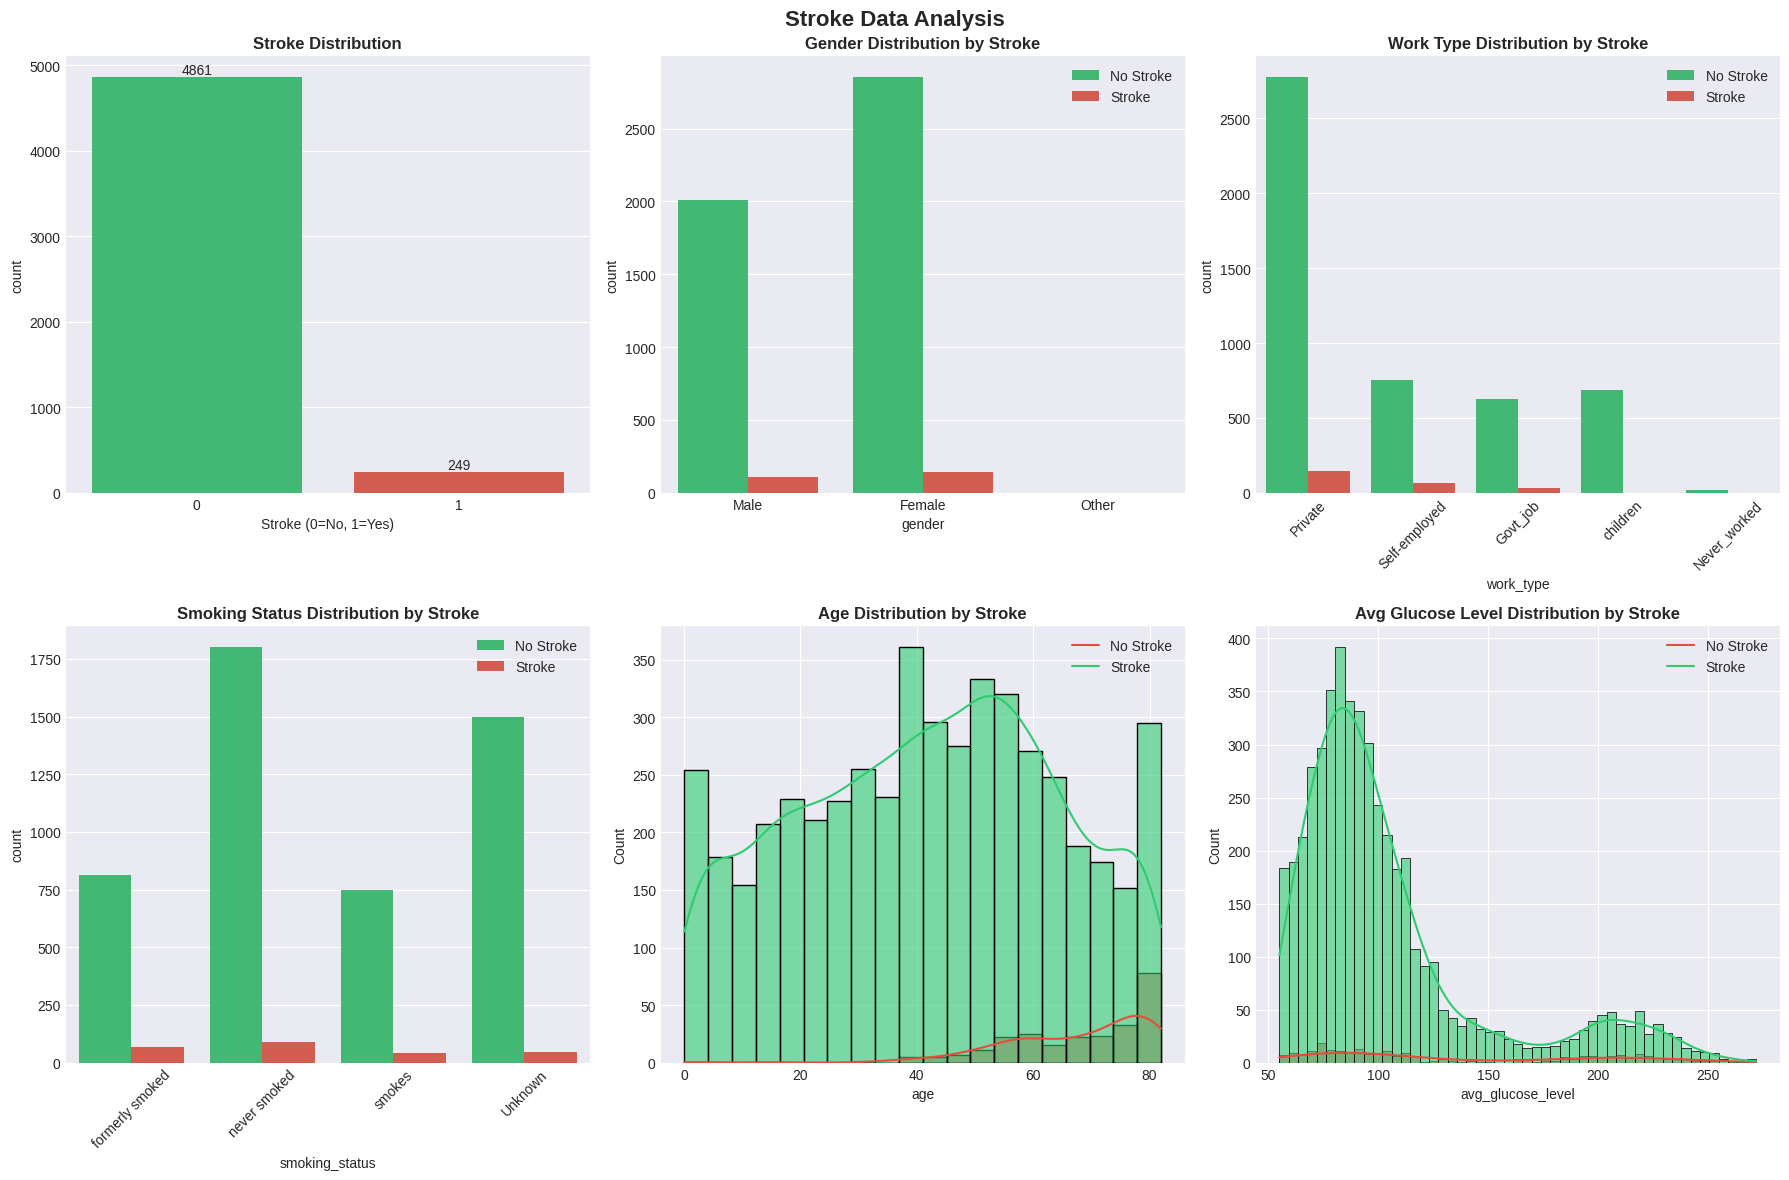

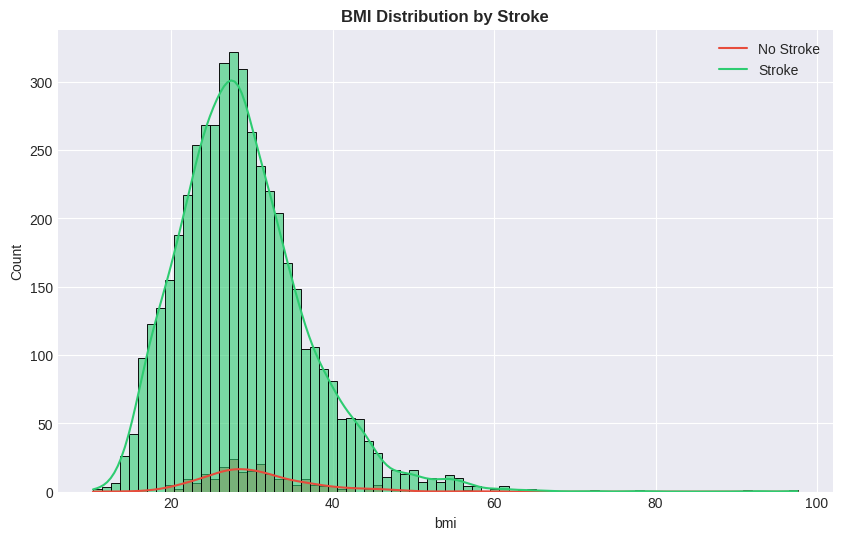

/tmp/ipykernel_375/2930861576.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_corr['bmi'].fillna(df_corr['bmi'].median(), inplace=True)


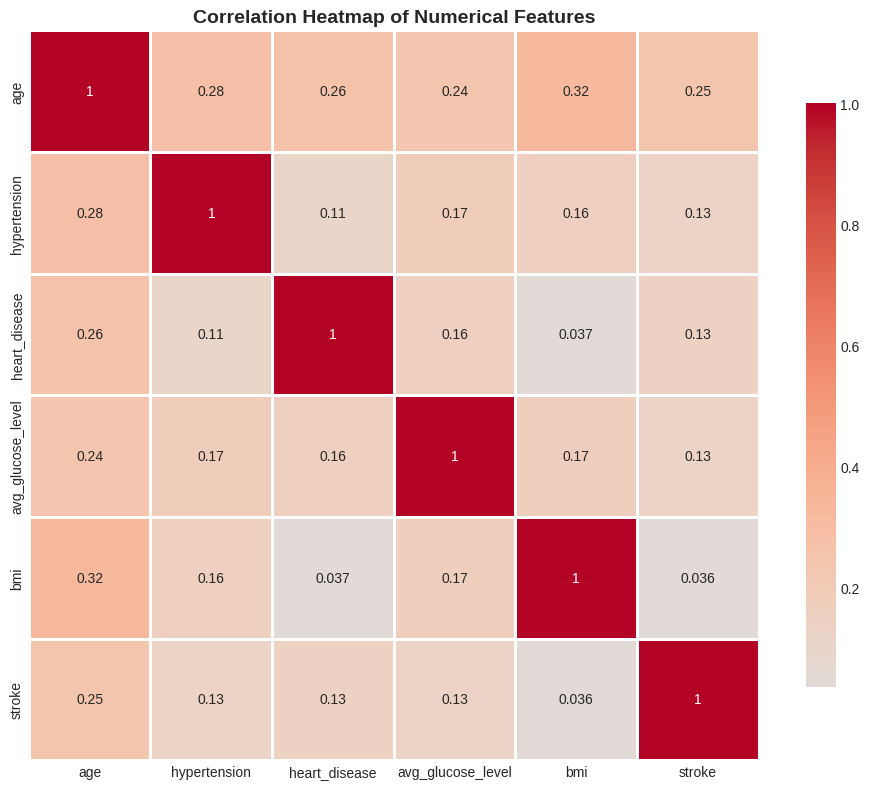

CORRELATION WITH STROKE
stroke               1.000000
age                  0.245239
heart_disease        0.134905
avg_glucose_level    0.131991
hypertension         0.127891
bmi                  0.036075
Name: stroke, dtype: float64


In [3]:
# 1. Create countplot for stroke column (class distribution)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Stroke Data Analysis', fontsize=16, fontweight='bold')

# Stroke distribution
sns.countplot(data=df, x='stroke', ax=axes[0, 0], palette=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Stroke Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Stroke (0=No, 1=Yes)')
for i in axes[0, 0].containers:
    axes[0, 0].bar_label(i)

# 2. Create countplots with hue='stroke' for gender, work_type, smoking_status
# Gender vs Stroke
sns.countplot(data=df, x='gender', hue='stroke', ax=axes[0, 1], palette=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Gender Distribution by Stroke', fontweight='bold')
axes[0, 1].legend(['No Stroke', 'Stroke'])

# Work Type vs Stroke
sns.countplot(data=df, x='work_type', hue='stroke', ax=axes[0, 2], palette=['#2ecc71', '#e74c3c'])
axes[0, 2].set_title('Work Type Distribution by Stroke', fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].legend(['No Stroke', 'Stroke'])

# Smoking Status vs Stroke
sns.countplot(data=df, x='smoking_status', hue='stroke', ax=axes[1, 0], palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Smoking Status Distribution by Stroke', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(['No Stroke', 'Stroke'])

# 3. Drop 'Other' gender record (only 1 exists)
print(f"Gender values before dropping 'Other': {df['gender'].unique()}")
df = df[df['gender'] != 'Other']
print(f"Gender values after dropping 'Other': {df['gender'].unique()}")
print(f"Shape after dropping 'Other': {df.shape}\n")

# 4. Create histograms/KDE plots for age, avg_glucose_level, bmi
# Age distribution by stroke
sns.histplot(data=df, x='age', hue='stroke', kde=True, ax=axes[1, 1],
             palette=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[1, 1].set_title('Age Distribution by Stroke', fontweight='bold')
axes[1, 1].legend(['No Stroke', 'Stroke'])

# Avg Glucose Level distribution by stroke
sns.histplot(data=df, x='avg_glucose_level', hue='stroke', kde=True, ax=axes[1, 2],
             palette=['#2ecc71', '#e74c3c'], alpha=0.6)
axes[1, 2].set_title('Avg Glucose Level Distribution by Stroke', fontweight='bold')
axes[1, 2].legend(['No Stroke', 'Stroke'])

plt.tight_layout()
plt.show()

# Create a separate plot for BMI since we have missing values
fig, ax = plt.subplots(figsize=(10, 6))
# Drop NA for visualization only
df_bmi_vis = df.dropna(subset=['bmi'])
sns.histplot(data=df_bmi_vis, x='bmi', hue='stroke', kde=True,
             palette=['#2ecc71', '#e74c3c'], alpha=0.6)
ax.set_title('BMI Distribution by Stroke', fontweight='bold')
ax.legend(['No Stroke', 'Stroke'])
plt.show()

# 5. Create correlation heatmap using selected numerical features and stroke
# First, handle missing values temporarily for correlation
df_corr = df.copy()
df_corr['bmi'].fillna(df_corr['bmi'].median(), inplace=True)

# Select numerical features
numerical_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
correlation_matrix = df_corr[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Print correlation with stroke
print("CORRELATION WITH STROKE")

print(correlation_matrix['stroke'].sort_values(ascending=False))


MISSING VALUES CHECK
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Percentage of missing values:
id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.934234
smoking_status       0.000000
stroke               0.000000
dtype: float64


BMI Statistics:
count    4908.00000
mean       28.89456
std         7.85432
min        10.30000
25%        23.50000
50%        28.10000
75%        33.10000
max        97.60000
Name: bmi, dtype: float64

Filled BMI missing values with median: 28.1
VERIFY NO M

/tmp/ipykernel_375/2227569203.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(bmi_median, inplace=True)


OUTLIER ANALYSIS - AVG GLUCOSE LEVEL
Q1: 77.24, Q3: 114.09, IQR: 36.85
Lower bound: 21.96, Upper bound: 169.37
Number of outliers before: 627 (12.27%)
Capped outliers at IQR bounds


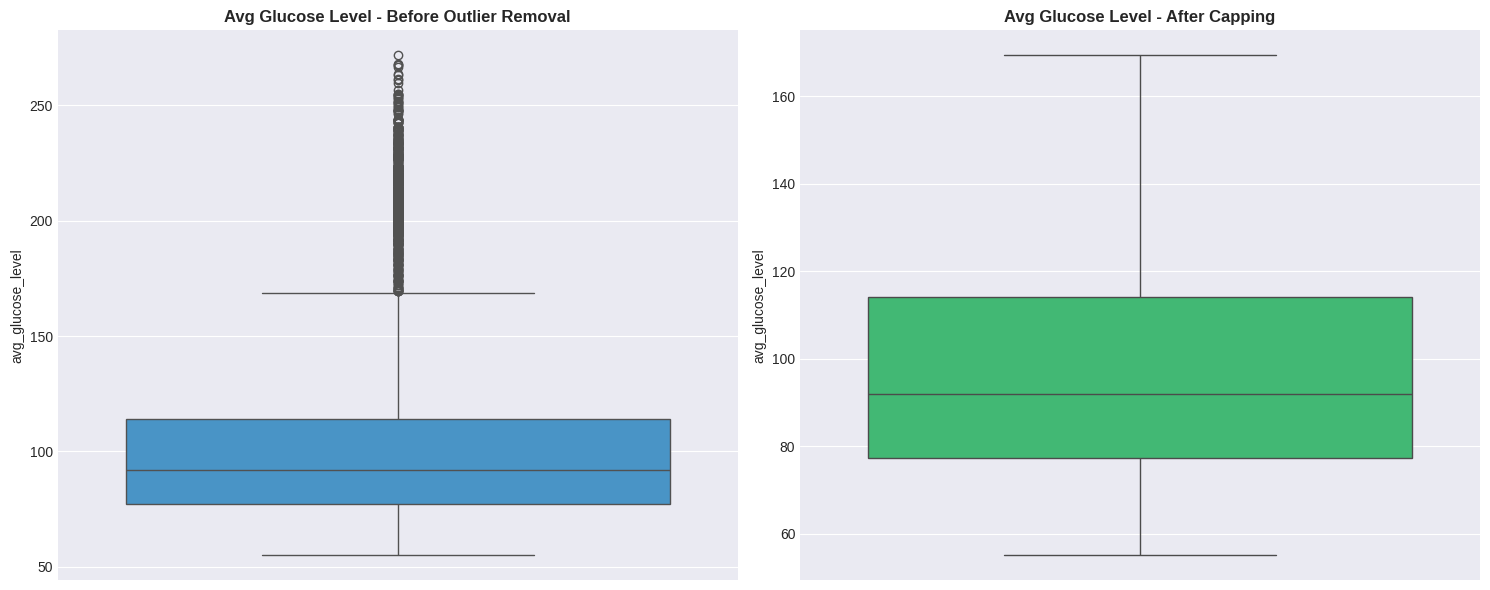

Number of outliers after capping: 0


In [4]:
# 1. Check for missing values

print("MISSING VALUES CHECK")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nPercentage of missing values:")
print((missing_values / len(df)) * 100)
print("\n")

# 2. Fill bmi missing values using median
# Let's check BMI distribution
print("BMI Statistics:")
print(df['bmi'].describe())

# Fill with median (more robust than mean for skewed data)
bmi_median = df['bmi'].median()
df['bmi'].fillna(bmi_median, inplace=True)
print(f"\nFilled BMI missing values with median: {bmi_median}")

# 3. Verify no missing values remain
print("VERIFY NO MISSING VALUES REMAIN")
print(df.isnull().sum())
print("\n")

# 4. Check for duplicates and remove them if any exist
print("DUPLICATE CHECK")
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicate_count} duplicates. New shape: {df.shape}")
else:
    print("No duplicates found.")
print("\n")

# 5. Drop id column (no predictive power)
df.drop('id', axis=1, inplace=True)
print("Dropped 'id' column")
print(f"Columns now: {df.columns.tolist()}")
print("\n")

# 6. Create boxplot for avg_glucose_level to detect outliers and remove if needed
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot before outlier removal
sns.boxplot(data=df, y='avg_glucose_level', ax=axes[0], color='#3498db')
axes[0].set_title('Avg Glucose Level - Before Outlier Removal', fontweight='bold')

# Calculate IQR for avg_glucose_level
Q1 = df['avg_glucose_level'].quantile(0.25)
Q3 = df['avg_glucose_level'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("OUTLIER ANALYSIS - AVG GLUCOSE LEVEL")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

outliers_before = df[(df['avg_glucose_level'] < lower_bound) | (df['avg_glucose_level'] > upper_bound)]
print(f"Number of outliers before: {len(outliers_before)} ({len(outliers_before)/len(df)*100:.2f}%)")


#  Cap outliers (recommended for medical data)
df['avg_glucose_level'] = df['avg_glucose_level'].clip(lower=lower_bound, upper=upper_bound)
print("Capped outliers at IQR bounds")

# Boxplot after capping
sns.boxplot(data=df, y='avg_glucose_level', ax=axes[1], color='#2ecc71')
axes[1].set_title('Avg Glucose Level - After Capping', fontweight='bold')

plt.tight_layout()
plt.show()

# Verify no extreme outliers remain
outliers_after = df[(df['avg_glucose_level'] < lower_bound) | (df['avg_glucose_level'] > upper_bound)]
print(f"Number of outliers after capping: {len(outliers_after)}")


In [5]:
# 1. Encode categorical variables

print("CATEGORICAL VARIABLES ENCODING")


# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")
print(f"Unique values in each categorical column:")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique()}")

# 2. Reset DataFrame index (good practice before transformations)
df.reset_index(drop=True, inplace=True)

# 3. Apply one-hot encoding using pd.get_dummies()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nShape after one-hot encoding: {df_encoded.shape}")
print(f"Columns after encoding: {df_encoded.columns.tolist()}")




CATEGORICAL VARIABLES ENCODING
Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Unique values in each categorical column:
  gender: ['Male' 'Female']
  ever_married: ['Yes' 'No']
  work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
  Residence_type: ['Urban' 'Rural']
  smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']

Shape after one-hot encoding: (5109, 16)
Columns after encoding: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']


In [6]:
# 1. Separate features X and target y
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']
print("FEATURE-TARGET SEPARATION")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Target distribution (%):\n{y.value_counts(normalize=True) * 100}")
print("\n")

# 2. Use train_test_split() with 80/20 ratio and random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Verify shapes
print("TRAIN-TEST SPLIT VERIFICATION")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\n")

print(f"Training set stroke distribution:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\nTest set stroke distribution:")
print(y_test.value_counts(normalize=True) * 100)

FEATURE-TARGET SEPARATION
X shape: (5109, 15)
y shape: (5109,)
Target distribution:
stroke
0    4860
1     249
Name: count, dtype: int64
Target distribution (%):
stroke
0    95.126248
1     4.873752
Name: proportion, dtype: float64


TRAIN-TEST SPLIT VERIFICATION
X_train shape: (4087, 15)
X_test shape: (1022, 15)
y_train shape: (4087,)
y_test shape: (1022,)


Training set stroke distribution:
stroke
0    95.130903
1     4.869097
Name: proportion, dtype: float64

Test set stroke distribution:
stroke
0    95.107632
1     4.892368
Name: proportion, dtype: float64


In [7]:
# 1. Import StandardScaler (already imported)
# 2. Scale numerical features: age, avg_glucose_level, bmi
numerical_features = ['age', 'avg_glucose_level', 'bmi']

# Check if these features exist in the encoded dataframe
available_num_features = [f for f in numerical_features if f in X_train.columns]
print(f"Numerical features to scale: {available_num_features}")

# 3. Fit scaler on training data only, then transform both train and test sets
scaler = StandardScaler()

# Fit on training data
scaler.fit(X_train[available_num_features])

# Transform both train and test sets
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[available_num_features] = scaler.transform(X_train[available_num_features])
X_test_scaled[available_num_features] = scaler.transform(X_test[available_num_features])

# Verify scaling worked
print("\nBefore Scaling - Training Data:")
print(X_train[available_num_features].describe().loc[['mean', 'std']])

print("\nAfter Scaling - Training Data:")
print(X_train_scaled[available_num_features].describe().loc[['mean', 'std']])



Numerical features to scale: ['age', 'avg_glucose_level', 'bmi']

Before Scaling - Training Data:
            age  avg_glucose_level        bmi
mean  43.259369         100.945783  28.850771
std   22.642243          32.970435   7.737596

After Scaling - Training Data:
               age  avg_glucose_level           bmi
mean -1.373449e-16       3.711790e-16 -2.712128e-16
std   1.000122e+00       1.000122e+00  1.000122e+00


In [ ]:
# 1. Check distribution of stroke
print("CLASS IMBALANCE ANALYSIS")
print("Original training set distribution:")
print(y_train.value_counts())
print(f"Percentage: {y_train.value_counts(normalize=True) * 100}")

# Visualize imbalance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original distribution
sns.countplot(x=y_train, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Original Training Set - Stroke Distribution', fontweight='bold')
axes[0].set_xlabel('Stroke')
for i in axes[0].containers:
    axes[0].bar_label(i)

# 2. Apply SMOTE (Synthetic Minority Over-sampling Technique)
print("APPLYING SMOTE")


# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to training data only (never to test data!)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE - Training set distribution:")
print(y_train_resampled.value_counts())
print(f"Percentage: {y_train_resampled.value_counts(normalize=True) * 100}")

# Visualize after SMOTE
sns.countplot(x=y_train_resampled, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE - Training Set Distribution', fontweight='bold')
axes[1].set_xlabel('Stroke')
for i in axes[1].containers:
    axes[1].bar_label(i)

# Comparison bar chart
comparison_data = pd.DataFrame({
    'Class': ['No Stroke', 'Stroke'] * 2,
    'Count': [
        sum(y_train == 0), sum(y_train == 1),
        sum(y_train_resampled == 0), sum(y_train_resampled == 1)
    ],
    'Dataset': ['Original']*2 + ['After SMOTE']*2
})

sns.barplot(data=comparison_data, x='Class', y='Count', hue='Dataset', ax=axes[2])
axes[2].set_title('Class Distribution Comparison', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Verify balanced distribution
print("FINAL VERIFICATION")
print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")
print(f"X_test_scaled shape (unchanged): {X_test_scaled.shape}")
print(f"y_test shape (unchanged): {y_test.shape}")

In [8]:
print("\n" + "="*70)
print("HIGH-RISK STROKE PATIENT PERSONA")
print("="*70)

# Analyze the original data to create persona
high_risk = df[df['stroke'] == 1]

print("\nBased on the analysis of stroke patients in the dataset:")
print("-" * 50)

# Age analysis
avg_age_stroke = high_risk['age'].mean()
print(f"• Average age of stroke patients: {avg_age_stroke:.1f} years")

# Gender analysis
gender_stroke = high_risk['gender'].value_counts(normalize=True) * 100
print(f"• Gender distribution: {gender_stroke.to_dict()}")

# Hypertension analysis
hyp_stroke = high_risk['hypertension'].mean() * 100
print(f"• {hyp_stroke:.1f}% of stroke patients have hypertension")

# Heart disease analysis
heart_stroke = high_risk['heart_disease'].mean() * 100
print(f"• {heart_stroke:.1f}% of stroke patients have heart disease")

# Glucose analysis
avg_glucose_stroke = high_risk['avg_glucose_level'].mean()
print(f"• Average glucose level: {avg_glucose_stroke:.1f}")

# BMI analysis
avg_bmi_stroke = high_risk['bmi'].mean()
print(f"• Average BMI: {avg_bmi_stroke:.1f}")

# Smoking status
smoking_stroke = high_risk['smoking_status'].value_counts(normalize=True) * 100
print(f"• Smoking status distribution: {smoking_stroke.to_dict()}")

print("\n" + "="*70)
print("PERSONA: The High-Risk Stroke Patient")




HIGH-RISK STROKE PATIENT PERSONA

Based on the analysis of stroke patients in the dataset:
--------------------------------------------------
• Average age of stroke patients: 67.7 years
• Gender distribution: {'Female': 56.62650602409639, 'Male': 43.373493975903614}
• 26.5% of stroke patients have hypertension
• 18.9% of stroke patients have heart disease
• Average glucose level: 118.0
• Average BMI: 30.1
• Smoking status distribution: {'never smoked': 36.144578313253014, 'formerly smoked': 28.11244979919679, 'Unknown': 18.87550200803213, 'smokes': 16.867469879518072}

PERSONA: The High-Risk Stroke Patient
